In [1]:
import gensim.downloader as api
from gensim.models import FastText
from gensim.utils import simple_preprocess
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import fasttext
import fasttext.util
import pandas as pd
import seaborn as sns

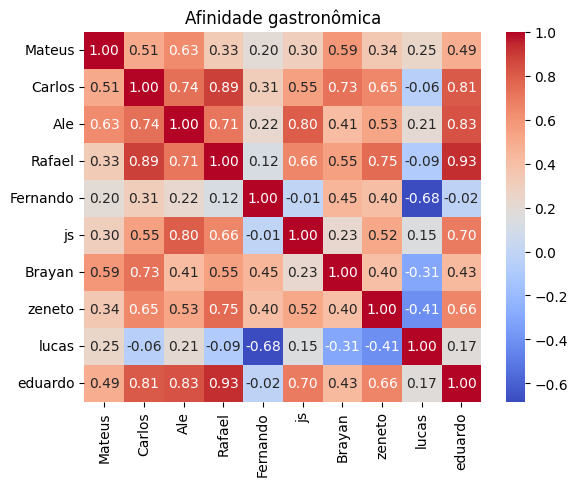

In [2]:
df = pd.read_csv("food.csv")

names = df["nome"].tolist()
vectors = df.drop(columns=["nome"]).values
vectors_centered = vectors - vectors.mean(axis=1, keepdims=True)

sim_matrix = cosine_similarity(vectors_centered)

sns.heatmap(sim_matrix, xticklabels=names, yticklabels=names,
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Afinidade gastronômica")
plt.show()

In [3]:
#fasttext.util.download_model('pt', if_exists='ignore')
ft = fasttext.load_model('cc.pt.300.bin')

In [4]:
dictionary_words = pd.read_csv("../session_4_dba/data/dict.csv", sep=";")["answer"]

In [5]:
for word in dictionary_words:
    neighbors = ft.get_nearest_neighbors(word, k=5)
    print(f"\n{word}:")
    for score, neighbor in neighbors:
        print(f"  {neighbor} ({score:.3f})")


comunismo:
  socialismo (0.827)
  Comunismo (0.797)
  comunista (0.756)
  stalinismo (0.728)
  marxismo (0.721)

lula:
  lula. (0.672)
  dilma (0.619)
  lulas (0.609)
  molusco (0.594)
  dorê (0.575)

socialismo:
  comunismo (0.827)
  marxismo (0.756)
  capitalismo (0.753)
  socialista (0.752)
  Socialismo (0.748)

revolução:
  Revolução (0.771)
  revolucionária (0.740)
  arevolução (0.731)
  contra-revolução (0.716)
  revoluçao (0.695)

esquerda:
  direita (0.957)
  esquerda.A (0.773)
  direira (0.747)
  esqueda (0.735)
  aesquerda (0.723)

esquerdista:
  direitista (0.810)
  esquerdopata (0.765)
  ex-esquerdista (0.748)
  anti-esquerdista (0.742)
  esquerdismo (0.729)

marx:
  karl (0.697)
  Marx. (0.653)
  Marx.A (0.618)
  nietzsche (0.595)
  marxiano (0.584)

aborto:
  abortamento (0.761)
  aborto.O (0.747)
  Aborto (0.735)
  abortos (0.732)
  abortoO (0.711)

sindicato:
  Sindicato (0.791)
  sindicatos (0.716)
  sindical (0.715)
  sindicato.O (0.709)
  sindicado (0.706)

vermelha

In [6]:
data = pd.read_csv("../session_4_dba/data/fakeWhatsApp.BR_2018_content_only.csv")

In [7]:
corpus = [simple_preprocess(doc) for doc in data["text"]]

model = FastText(sentences=corpus, vector_size=300, window=5, min_count=5, epochs=20)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [8]:
for word in dictionary_words:
    neighbors = model.wv.most_similar(word, topn=5)
    print(f"\n{word}:")
    for neighbor, score in neighbors:
        print(f"  {neighbor} ({score:.3f})")


comunismo:
  comuns (0.821)
  comunista (0.801)
  comunistas (0.775)
  stalinismo (0.739)
  comungar (0.705)

lula:
  fórmula (0.796)
  luladrão (0.723)
  jaula (0.665)
  medula (0.660)
  lulo (0.627)

socialismo:
  socialista (0.766)
  stalinismo (0.732)
  social (0.732)
  socialistas (0.732)
  talismã (0.718)

revolução:
  evolução (0.954)
  devolução (0.897)
  solução (0.873)
  resolução (0.859)
  revogação (0.839)

esquerda:
  esquerdopata (0.927)
  esquerdo (0.921)
  esquerdas (0.880)
  esquerdismo (0.852)
  esquerdopatas (0.848)

esquerdista:
  esquerdopata (0.905)
  esquerdistas (0.868)
  esquerdo (0.861)
  esquerdismo (0.845)
  esquerda (0.807)

marx:
  maré (0.929)
  marka (0.905)
  marrom (0.881)
  marli (0.857)
  março (0.837)

aborto:
  morto (0.657)
  porto (0.649)
  aberto (0.620)
  importo (0.579)
  aeroporto (0.576)

sindicato:
  sindical (0.859)
  sindicatos (0.845)
  sindipetro (0.758)
  indica (0.721)
  indice (0.719)

vermelha:
  verme (0.831)
  vermelho (0.814)
  

In [9]:
word = "lula"

print("PRETRAINED:")
for score, neighbor in ft.get_nearest_neighbors(word, k=5):
    print(f"  {neighbor} ({score:.3f})")

print("\nTRAINED ON WHATSAPP:")
for neighbor, score in model.wv.most_similar(word, topn=5):
    print(f"  {neighbor} ({score:.3f})")

PRETRAINED:
  lula. (0.672)
  dilma (0.619)
  lulas (0.609)
  molusco (0.594)
  dorê (0.575)

TRAINED ON WHATSAPP:
  fórmula (0.796)
  luladrão (0.723)
  jaula (0.665)
  medula (0.660)
  lulo (0.627)


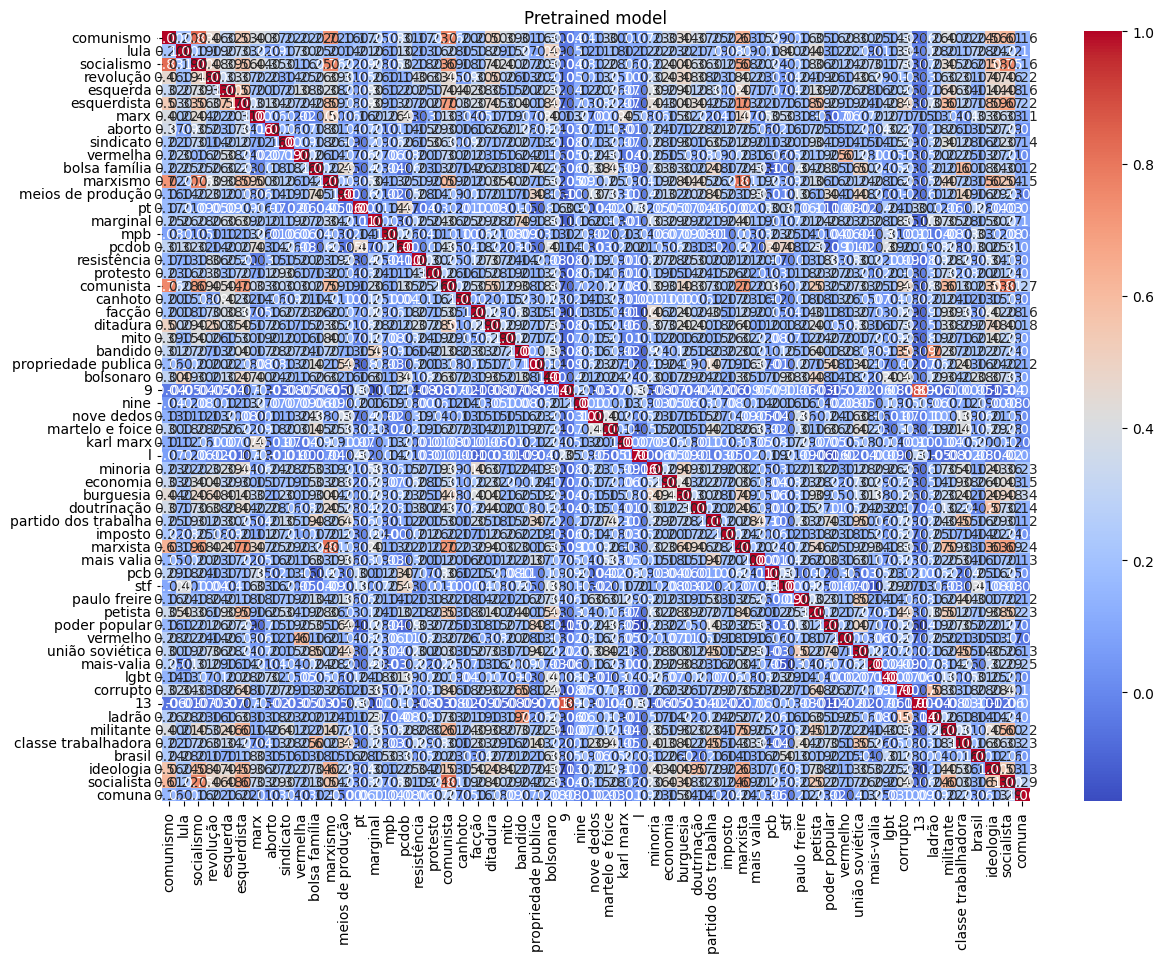

In [10]:
# Pretrained
vectors = np.array([ft.get_word_vector(w) for w in dictionary_words])
sim_matrix = cosine_similarity(vectors)
plt.figure(figsize=(14, 10))
sns.heatmap(sim_matrix, xticklabels=dictionary_words, yticklabels=dictionary_words, 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pretrained model")
plt.show()

In [11]:
# Get vectors
vectors = np.array([ft.get_word_vector(w) for w in dictionary_words])

centroid = vectors.mean(axis=0)
sim_to_centroid = cosine_similarity(vectors, centroid.reshape(1, -1)).flatten()

ranking = pd.DataFrame({
    "word": dictionary_words,
    "sim_to_centroid": sim_to_centroid
}).sort_values("sim_to_centroid", ascending=False)

print(ranking)

# Keep top N most central words
top_words = ranking.head(20)["word"].tolist()

                    word  sim_to_centroid
19             comunista         0.602964
16                 pcdob         0.578828
5            esquerdista         0.570633
0              comunismo         0.554751
26             bolsonaro         0.547056
2             socialismo         0.545025
39              marxista         0.543856
57            socialista         0.541993
6                   marx         0.538450
13                    pt         0.528108
11              marxismo         0.526527
44               petista         0.506707
56             ideologia         0.496744
42                   stf         0.487549
55                brasil         0.486626
1                   lula         0.485367
22              ditadura         0.475451
41                   pcb         0.471592
53             militante         0.470104
35             burguesia         0.468711
4               esquerda         0.457475
49                  lgbt         0.444888
24               bandido         0

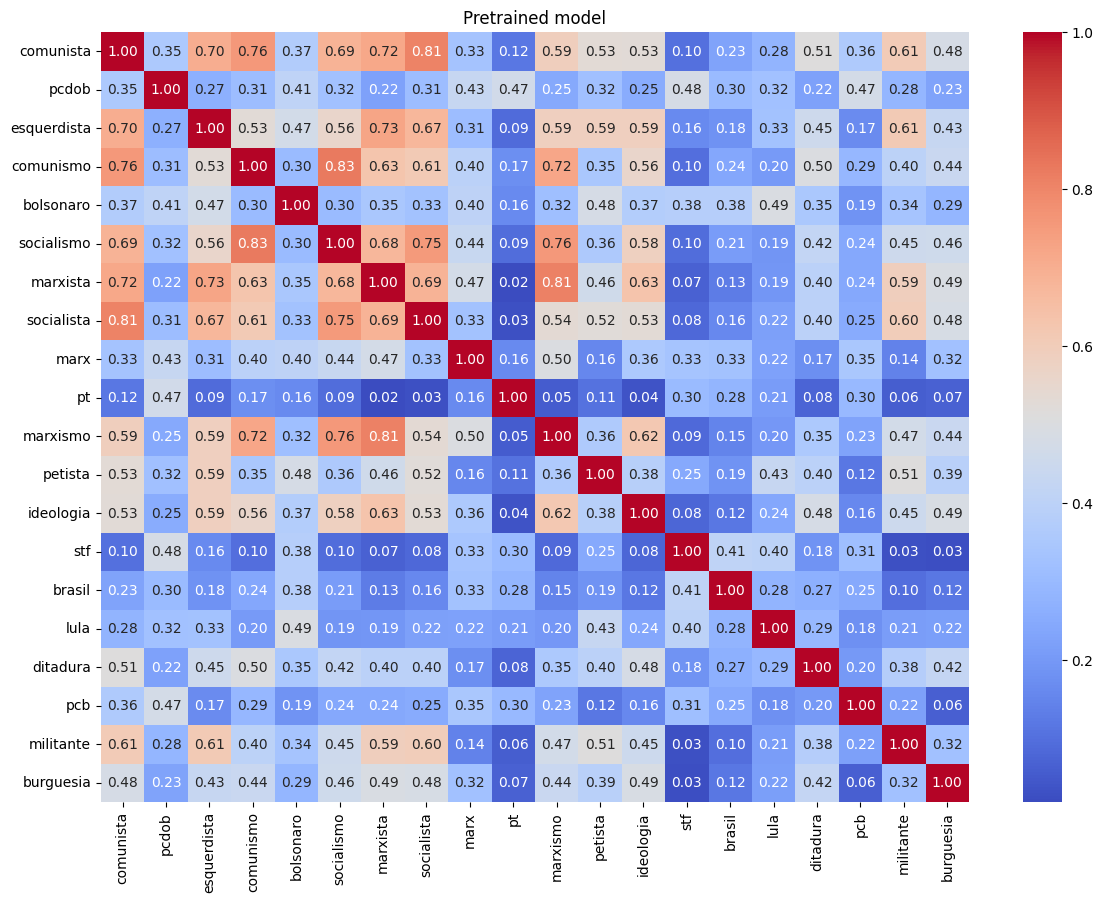

In [12]:
# Pretrained
vectors = np.array([ft.get_word_vector(w) for w in top_words])
sim_matrix = cosine_similarity(vectors)
plt.figure(figsize=(14, 10))
sns.heatmap(sim_matrix, xticklabels=top_words, yticklabels=top_words, 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pretrained model")
plt.show()

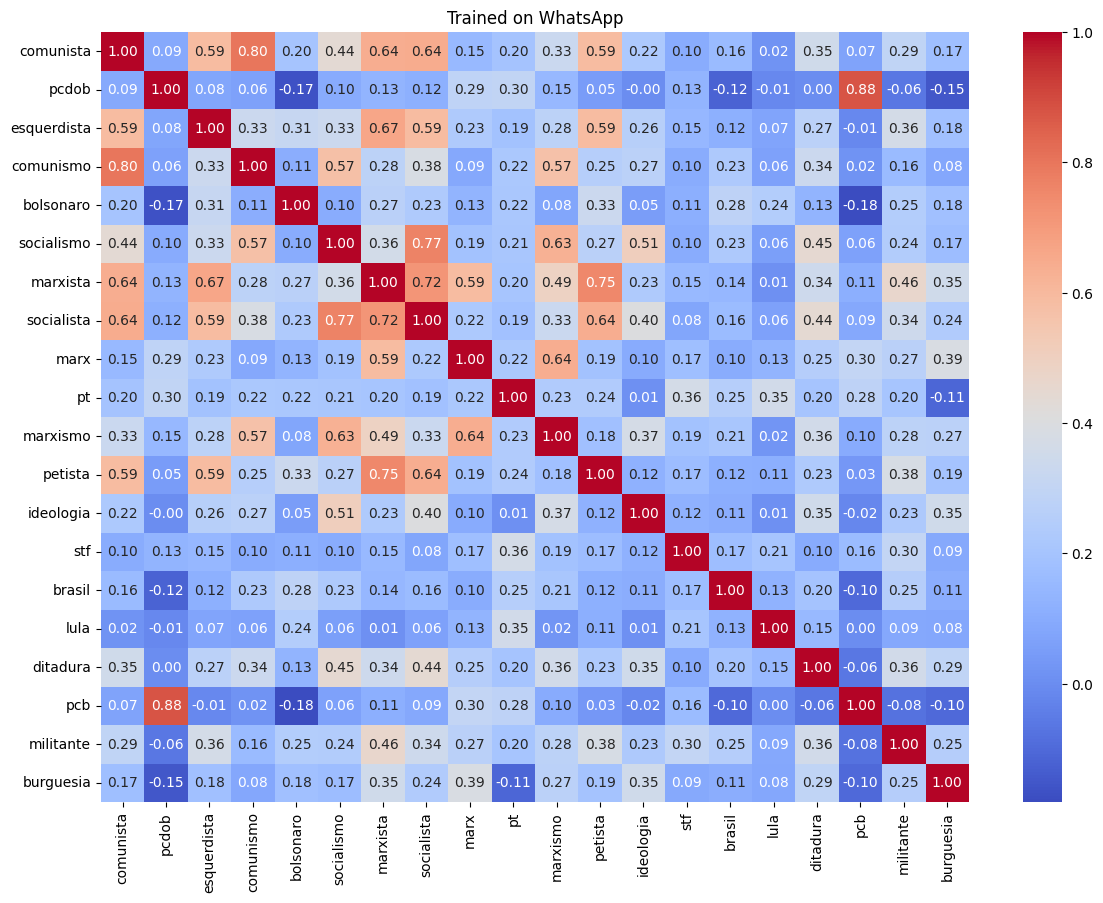

In [13]:
vectors_trained = np.array([model.wv[w] for w in top_words])
sim_matrix_trained = cosine_similarity(vectors_trained)
plt.figure(figsize=(14, 10))
sns.heatmap(sim_matrix_trained, xticklabels=top_words, yticklabels=top_words, 
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Trained on WhatsApp")
plt.show()

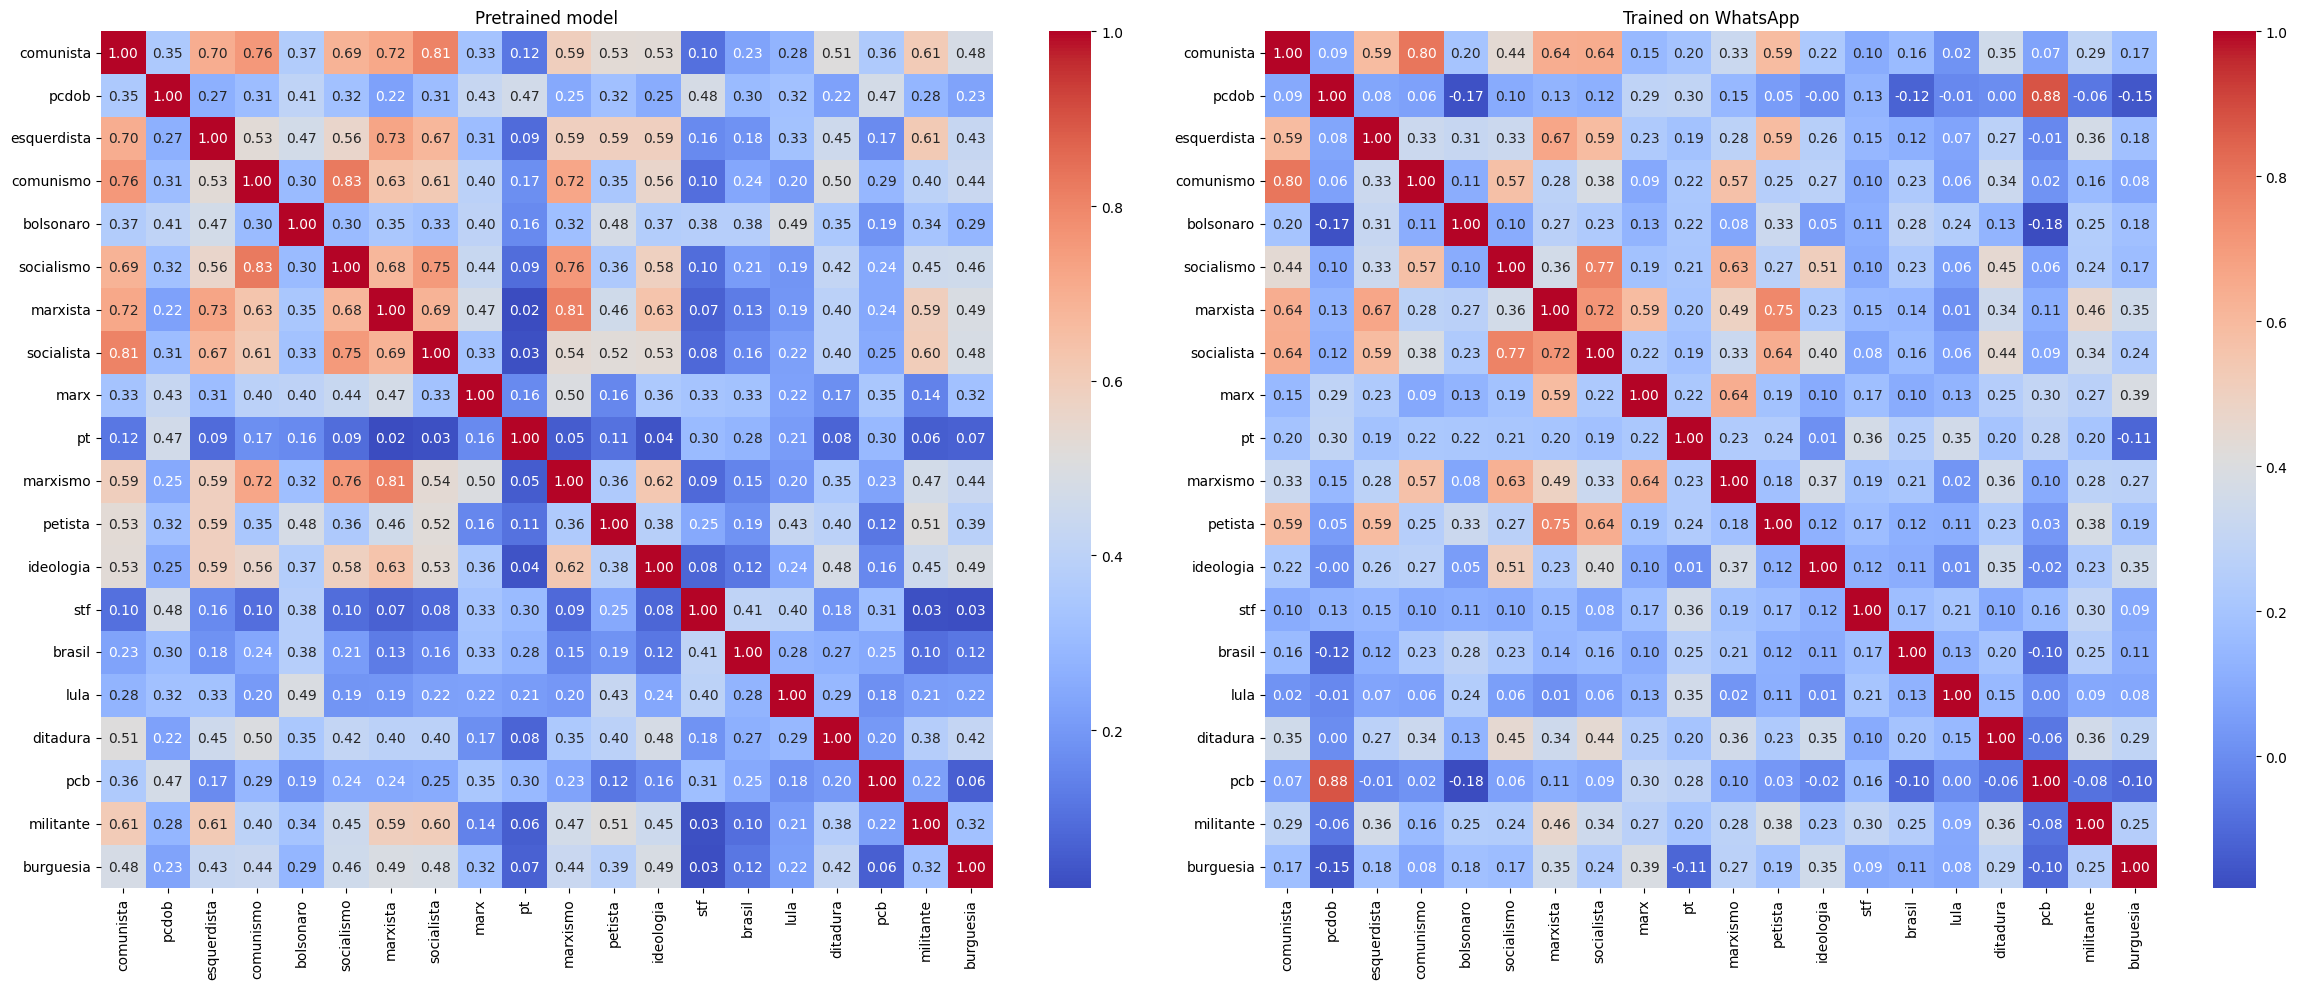

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(sim_matrix, xticklabels=top_words, yticklabels=top_words,
            annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Pretrained model")

sns.heatmap(sim_matrix_trained, xticklabels=top_words, yticklabels=top_words,
            annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Trained on WhatsApp")

plt.tight_layout()
plt.show()

In [15]:
# Prune words below threshold
pruning_threshold = ranking["sim_to_centroid"].median()
refined = ranking[ranking["sim_to_centroid"] >= pruning_threshold]
refined_words = refined["word"].tolist()
print(f"Kept {len(refined_words)} of {len(dictionary_words)} words after pruning")

# Find nearest neighbours for remaining words
expansion_threshold = 0.7
new_words = []

for word in refined_words:
    neighbors = ft.get_nearest_neighbors(word, k=3)
    for score, neighbor in neighbors:
        if (score >= expansion_threshold and 
            neighbor not in refined_words and 
            neighbor not in new_words):
            new_words.append({"word": neighbor, "source": word, "score": score})

expansion = pd.DataFrame(new_words).sort_values("score", ascending=False)
print(f"\nNew candidate words: {len(expansion)}")
print(expansion)

expanded_dictionary = refined_words + expansion["word"].tolist()
print(f"\nFinal dictionary size: {len(expanded_dictionary)}")

Kept 30 of 59 words after pruning

New candidate words: 46
                 word        source     score
33            direita      esquerda  0.956615
45        paulofreire  paulo freire  0.839887
1                pstu         pcdob  0.823314
24           Ditadura      ditadura  0.820658
4          direitista   esquerdista  0.809898
8          bolsonaros     bolsonaro  0.802167
7           Comunismo     comunismo  0.797414
17             tucano       petista  0.787582
14   social-democrata    socialista  0.784035
34         esquerda.A      esquerda  0.773309
30           burguesa     burguesia  0.771046
42          Revolução     revolução  0.770938
9        bolsonarokit     bolsonaro  0.770738
36              lgbts          lgbt  0.770370
18            petismo       petista  0.770360
16           Marxismo      marxismo  0.768623
5        esquerdopata   esquerdista  0.764544
22                stj           stf  0.762758
2                psol         pcdob  0.761697
12        neomarxista

In [16]:
new_words_trained = []

for word in refined_words:
    try:
        neighbors = model.wv.most_similar(word, topn=3)
        for neighbor, score in neighbors:
            if (score >= expansion_threshold and
                neighbor not in refined_words and
                neighbor not in new_words_trained):
                new_words_trained.append({"word": neighbor, "source": word, "score": score})
    except KeyError:
        print(f"Not in trained vocab: {word}")

expansion_trained = pd.DataFrame(new_words_trained).sort_values("score", ascending=False)
print(f"New candidate words: {len(expansion_trained)}")
print(expansion_trained)

New candidate words: 73
            word     source     score
9     jbolsonaro  bolsonaro  0.970391
59      evolução  revolução  0.953818
10   tvbolsonaro  bolsonaro  0.952554
11  soubolsonaro  bolsonaro  0.949149
35     jusbrasil     brasil  0.944804
..           ...        ...       ...
34           stj        stf  0.731096
24           ptc         pt  0.729268
62      original   marginal  0.726486
39      luladrão       lula  0.722529
63         sinal   marginal  0.714112

[73 rows x 3 columns]


In [17]:
# Words found by each model
pretrained_words = set(expansion["word"].tolist())
trained_words = set(expansion_trained["word"].tolist())

# Overlap
overlap = pretrained_words & trained_words
only_pretrained = pretrained_words - trained_words
only_trained = trained_words - pretrained_words

print(f"Found by pretrained only: {len(only_pretrained)}")
print(f"Found by trained only: {len(only_trained)}")
print(f"Found by both: {len(overlap)}")
print(f"Overlap words: {overlap}")

Found by pretrained only: 44
Found by trained only: 66
Found by both: 2
Overlap words: {'stj', 'esquerdopata'}


In [ ]:
# print("PRETRAINED:")
# results = ft.get_analogies("político", "homem", "mulher")
# for score, word in results:
#     print(f"  {word} ({score:.3f})")

# print("\nTRAINED ON WHATSAPP:")
# results_trained = model.wv.most_similar(positive=["político", "mulher"], negative=["homem"])
# for word, score in results_trained:
#     print(f"  {word} ({score:.3f})")

c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Exception in thread Thread-85 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\fabio\miniforge3\envs\nlp\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\fabio\miniforge3\envs\nlp\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\fabio\miniforge3\envs\nlp\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8a in position 112: invalid start byt

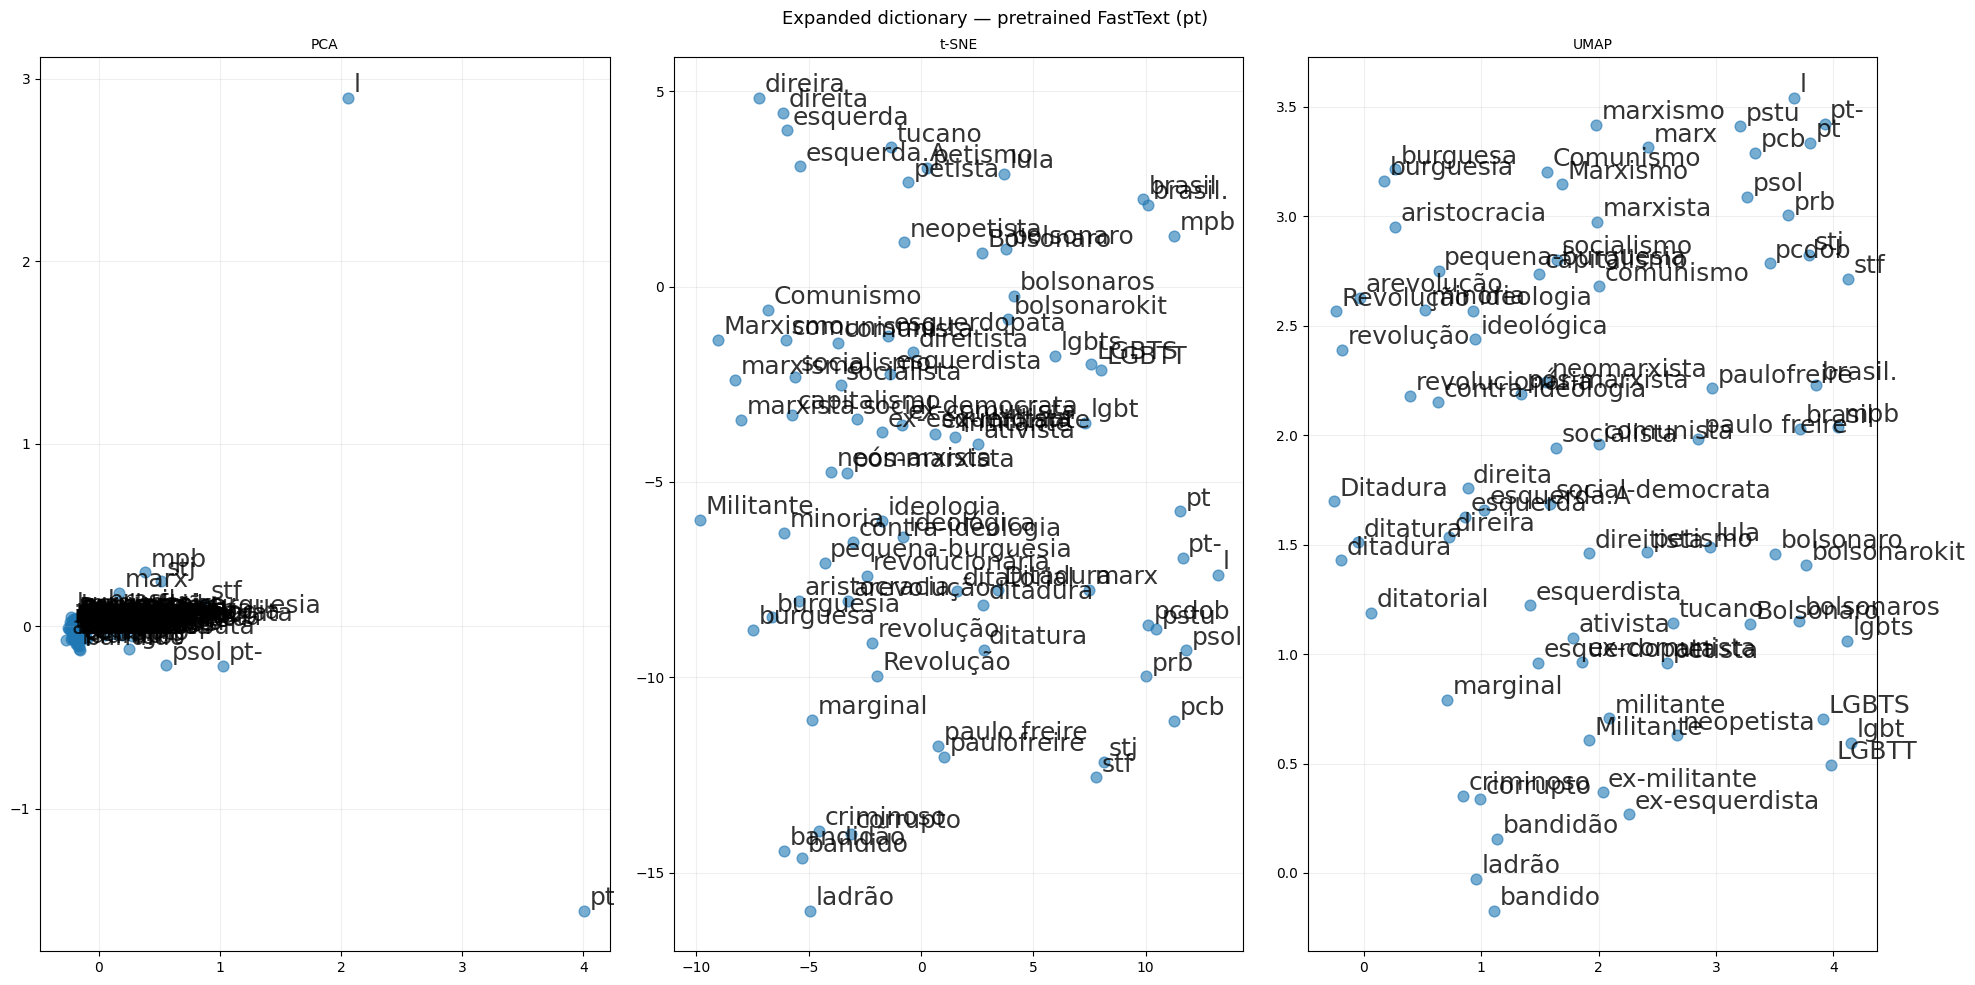

In [18]:
# Word-level dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

vecs = np.array([ft.get_word_vector(w) for w in expanded_dictionary])

reducers = {
    "PCA":   PCA(n_components=2),
    "t-SNE": TSNE(n_components=2, perplexity=15, random_state=42),
    "UMAP":  UMAP(n_components=2, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle("Expanded dictionary — pretrained FastText (pt)", fontsize=13)

for ax, (method_name, reducer) in zip(axes, reducers.items()):
    coords = reducer.fit_transform(vecs)
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=60)
    for i, word in enumerate(expanded_dictionary):
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    fontsize=18, alpha=0.8,
                    xytext=(4, 4), textcoords="offset points")
    ax.set_title(method_name, fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("word_dimreduction.png", dpi=150, bbox_inches="tight")
plt.show()

c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\fabio\miniforge3\envs\nlp\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


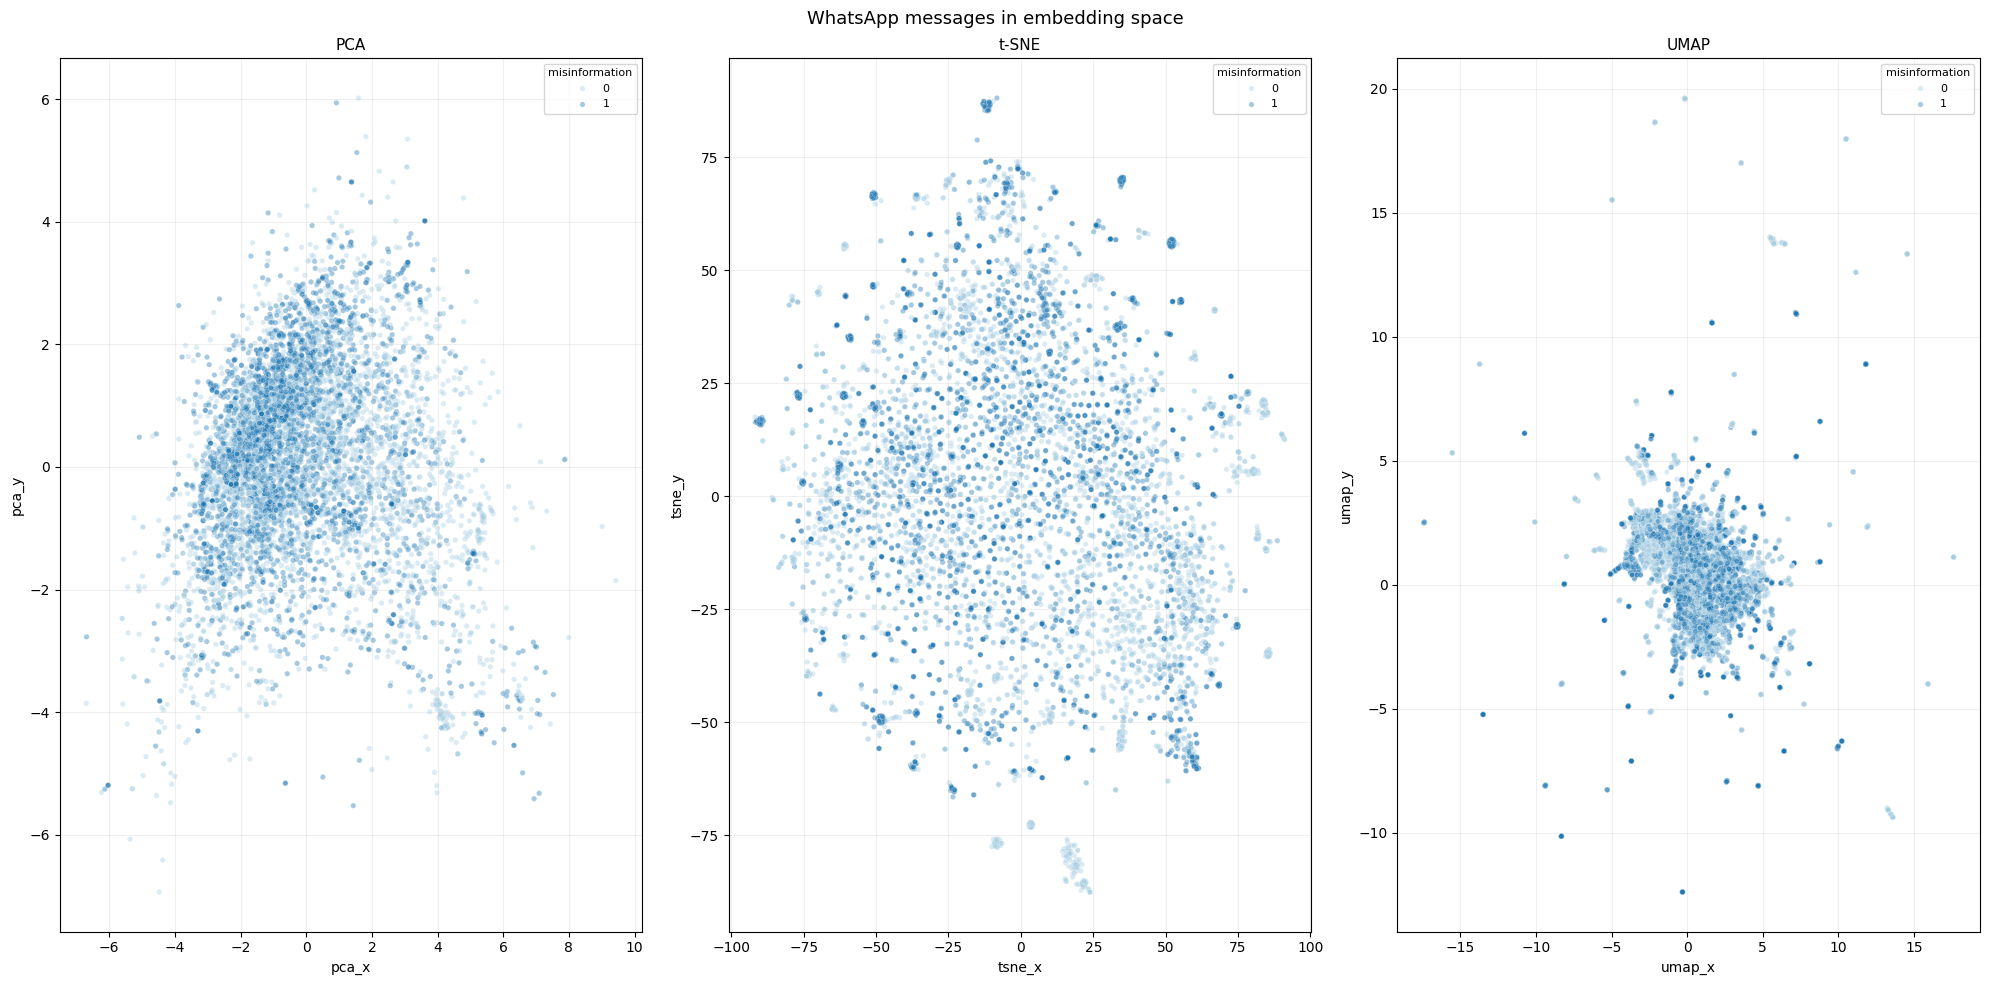

In [19]:
# Extract doc embeddings

def doc_vector(text, model_wv):
    tokens = simple_preprocess(str(text))
    vecs = [model_wv[w] for w in tokens if w in model_wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model_wv.vector_size)

data["vector"] = data["text"].apply(lambda t: doc_vector(t, model.wv))

mask = data["vector"].apply(lambda v: v.sum() != 0)
data_clean = data[mask].reset_index(drop=True)

doc_matrix = np.vstack(data_clean["vector"].values)

# Reduce to 2D
coords_umap = UMAP(n_components=2, random_state=42).fit_transform(doc_matrix)
coords_pca  = PCA(n_components=2).fit_transform(doc_matrix)
coords_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(doc_matrix)

data_clean["umap_x"], data_clean["umap_y"] = coords_umap[:, 0], coords_umap[:, 1]
data_clean["pca_x"],  data_clean["pca_y"]  = coords_pca[:, 0],  coords_pca[:, 1]
data_clean["tsne_x"], data_clean["tsne_y"] = coords_tsne[:, 0], coords_tsne[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle("WhatsApp messages in embedding space", fontsize=13)

for ax, (method, x_col, y_col) in zip(axes, [
    ("PCA",   "pca_x",   "pca_y"),
    ("t-SNE", "tsne_x",  "tsne_y"),
    ("UMAP",  "umap_x",  "umap_y"),
]):
    sns.scatterplot(
        data=data_clean, x=x_col, y=y_col,
        hue="misinformation",      
        alpha=0.4, s=15,
        palette="Paired", ax=ax
    )
    ax.set_title(method, fontsize=11)
    ax.grid(alpha=0.2)
    ax.legend(title="misinformation", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.savefig("doc_embeddings_misinfo.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Interactive plots with hover (PCA / t-SNE / UMAP)
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

data_clean["preview"] = data_clean["text"].str.slice(0, 200)

def make_plot(df, x, y, title):
    fig = px.scatter(
        df,
        x=x, y=y,
        color="misinformation",
        hover_data={
            "preview": True,  
            "misinformation": True
        },
        opacity=0.6,
        title=title,
        height=600
    )
    
    fig.update_traces(marker=dict(size=6))
    fig.update_layout(
        legend_title_text="misinformation",
        margin=dict(l=20, r=20, t=40, b=20)
    )
    
    fig.show()

make_plot(data_clean, "pca_x",  "pca_y",  "PCA — WhatsApp messages")
make_plot(data_clean, "tsne_x", "tsne_y", "t-SNE — WhatsApp messages")
make_plot(data_clean, "umap_x", "umap_y", "UMAP — WhatsApp messages")